# Jupyter Notebooks: Interactive Research Computing

Jupyter notebooks have transformed how researchers work with data. Instead of writing a script that runs from start to finish, you create an interactive document that mixes code, results, visualizations, and narrative text. It's like a lab notebook for computational research: you can experiment, document your thinking, and share your entire research process.

## What Makes Notebooks Special

Traditional programming separates code from its output. You write a script, run it, and see results in a terminal. Notebooks are different:

- **Interactive**: Run code in pieces, see results immediately
- **Iterative**: Modify and re-run cells without starting over
- **Visual**: Charts and tables appear inline with your code
- **Narrative**: Mix markdown text with code for documentation
- **Shareable**: Others can read and reproduce your entire analysis

## Starting Jupyter

You installed Jupyter earlier with `pip install jupyter`. Let's use it:

```bash
# In your terminal, navigate to your project folder
cd python_projects

# Start JupyterLab (the modern interface)
jupyter lab

# Or use classic Jupyter Notebook
jupyter notebook
```

Your browser will open with the Jupyter interface. Click "New" → "Python 3" to create your first notebook.

## Understanding Cells

Notebooks are made of cells. Each cell can be one of three types:

- **Code cells**: Contain Python code that can be executed
- **Markdown cells**: Contain formatted text for documentation
- **Raw cells**: Unformatted text (rarely used)

### Essential Shortcuts

Learning these shortcuts will transform your notebook experience:

- **Run cell**: `Shift + Enter` (run and move to next)
- **Run cell in place**: `Ctrl + Enter` (stay on same cell)
- **Command mode**: `Esc` (blue cell border)
- **Edit mode**: `Enter` (green cell border)

In command mode:
- **Add cell above**: `A`
- **Add cell below**: `B`
- **Delete cell**: `DD` (press D twice)
- **Change to Markdown**: `M`
- **Change to Code**: `Y`
- **Save notebook**: `Ctrl + S` or `Cmd + S`

## Your First Research Notebook

Let's create a real research notebook analyzing historical data:

In [37]:
%pip install numpy pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [46]:
# Cell 1: Setup and Imports
"""
Historical Weather Analysis
==========================
Analyzing temperature trends over time
Author: Your Name
Date: November 2024
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings for pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Setup complete.")

Setup complete.


## Data Collection

We'll analyze temperature data to understand climate patterns.

Our research questions:
1. How have temperatures changed over the past century?
2. Are seasonal patterns shifting?
3. Which regions show the most change?

In [48]:
# Cell 3: Generate Sample Data (in practice, you'd load real data)
np.random.seed(42)  # For reproducibility

# Create synthetic historical temperature data
years = range(1920, 2024)
months = range(1, 13)

data = []
for year in years:
    # Add slight warming trend
    base_temp = 15 + (year - 1920) * 0.02
    
    for month in months:
        # Seasonal variation
        seasonal = 10 * np.sin((month - 1) * np.pi / 6)
        
        # Random variation
        random_var = np.random.normal(0, 2)
        
        temp = base_temp + seasonal + random_var
        
        data.append({
            'year': year,
            'month': month,
            'temperature': round(temp, 1),
            'date': pd.Timestamp(year, month, 1)
        })

# Convert to DataFrame
df = pd.DataFrame(data)
print(f"Created {len(df)} temperature records")
df.head()

Created 1248 temperature records


,year,month,temperature,date
0,1920,1,16.0,1920-01-01
1,1920,2,19.7,1920-02-01
2,1920,3,25.0,1920-03-01
3,1920,4,28.0,1920-04-01
4,1920,5,23.2,1920-05-01


In [51]:
# Cell 4: Data Exploration
# Basic statistics
print("Dataset Overview")
print("=" * 50)
df.info()

print("\nTemperature Statistics")
print("=" * 50)
df['temperature'].describe()

Dataset Overview
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   year         1248 non-null   int64         
 1   month        1248 non-null   int64         
 2   temperature  1248 non-null   float64       
 3   date         1248 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 39.1 KB

Temperature Statistics


count    1248.000000
mean       16.107933
std         7.452405
min         0.300000
25%         9.275000
50%        16.200000
75%        22.800000
max        31.000000
Name: temperature, dtype: float64

In [52]:
# Cell 5: Create New Features
# Add decade column for grouping
df['decade'] = (df['year'] // 10) * 10

# Add season
def get_season(month):
    if month in [12, 1, 2]:
       return 'Winter' 
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['month'].apply(get_season)

# Calculate yearly averages
yearly_avg = df.groupby('year')['temperature'].mean().reset_index()
yearly_avg.columns = ['year', 'avg_temperature']

print("Feature engineering complete")
df.head()

Feature engineering complete


,year,month,temperature,date,decade,season
0,1920,1,16.0,1920-01-01,1920,Winter
1,1920,2,19.7,1920-02-01,1920,Winter
2,1920,3,25.0,1920-03-01,1920,Spring
3,1920,4,28.0,1920-04-01,1920,Spring
4,1920,5,23.2,1920-05-01,1920,Spring


## Data Visualization in Notebooks

One of Jupyter's greatest strengths is inline visualization:

In [55]:
# Cell 6: Visualization Setup
# Use this magic command to display plots inline
%matplotlib inline

# For interactive plots (optional)
# %matplotlib widget

# Set figure size defaults
plt.rcParams['figure.figsize'] = (12, 6)

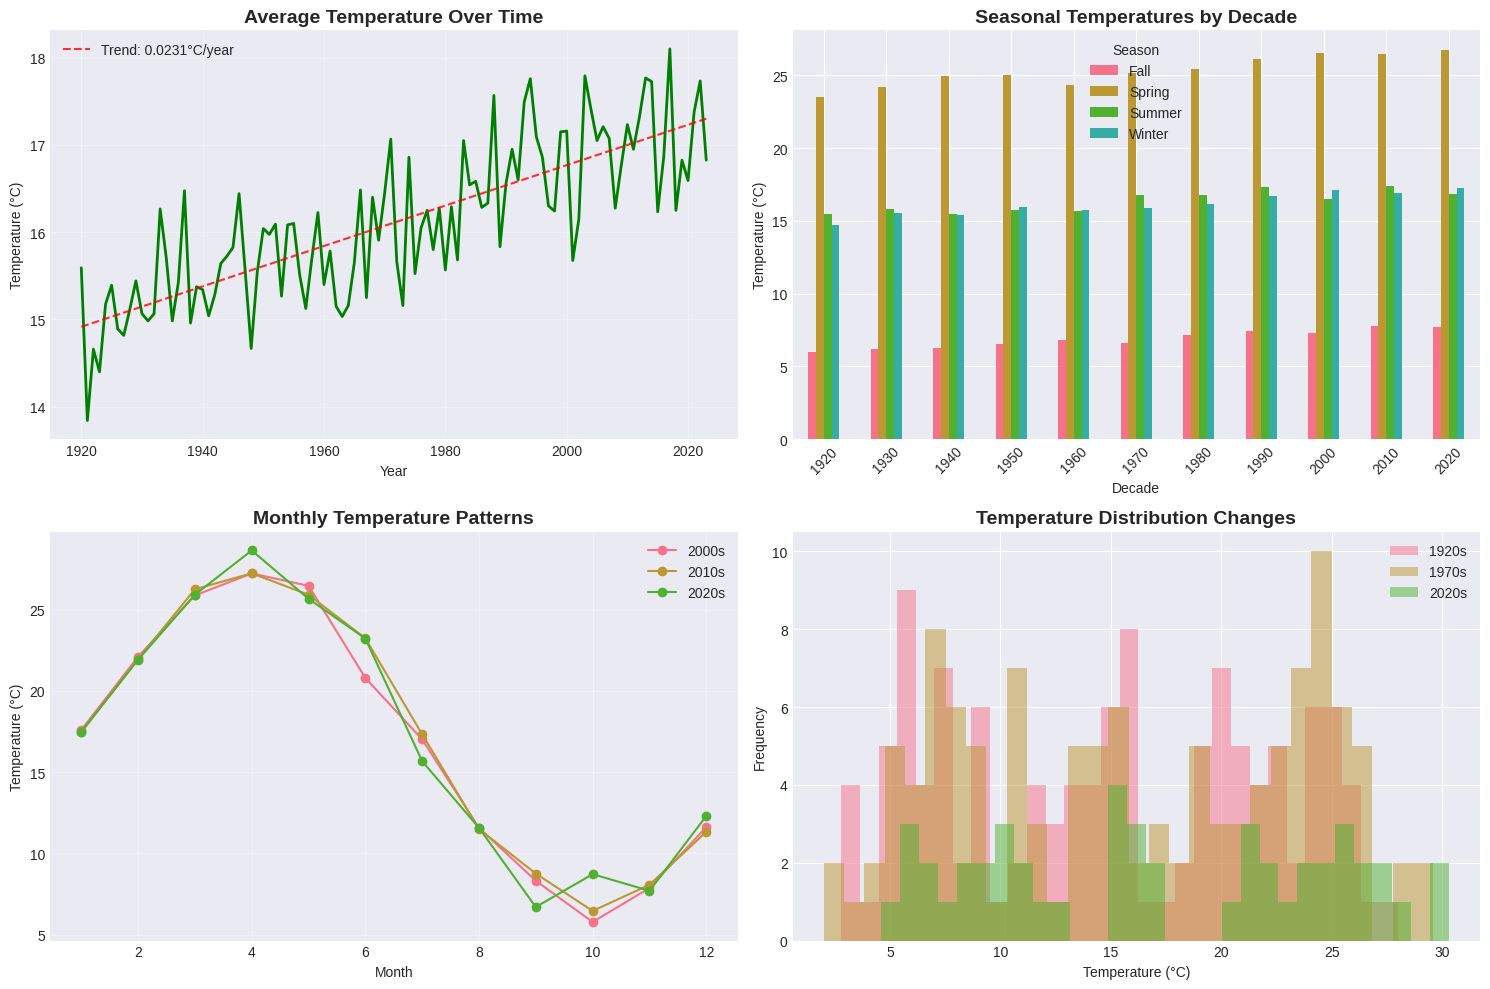


Temperature increase per decade:
1930s: +0.50°C from previous decade
1940s: +0.08°C from previous decade
1950s: +0.30°C from previous decade
1960s: -0.19°C from previous decade
1970s: +0.49°C from previous decade
1980s: +0.26°C from previous decade
1990s: +0.53°C from previous decade
2000s: -0.04°C from previous decade
2010s: +0.27°C from previous decade
2020s: +0.00°C from previous decade


In [60]:
# Cell 7: Temperature Trends
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Overall trend
ax1 = axes[0, 0]
ax1.plot(yearly_avg['year'], yearly_avg['avg_temperature'], 
         linewidth=2, color='green')
ax1.set_title('Average Temperature Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Temperature (°C)')
ax1.grid(True, alpha=0.3)

# # Add trend line
z = np.polyfit(yearly_avg['year'], yearly_avg['avg_temperature'], 1)
p = np.poly1d(z)
ax1.plot(yearly_avg['year'], p(yearly_avg['year']), 
         "r--", alpha=0.8, label=f'Trend: {z[0]:.4f}°C/year')
ax1.legend()

# 2. Seasonal patterns by decade
ax2 = axes[0, 1]
seasonal_avg = df.groupby(['decade', 'season'])['temperature'].mean().unstack()
seasonal_avg.plot(kind='bar', ax=ax2)
ax2.set_title('Seasonal Temperatures by Decade', fontsize=14, fontweight='bold')
ax2.set_xlabel('Decade')
ax2.set_ylabel('Temperature (°C)')
ax2.legend(title='Season')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)

# 3. Monthly distribution
ax3 = axes[1, 0]
monthly_temps = df.pivot_table(values='temperature', 
                                index='month', 
                                columns='decade', 
                                aggfunc='mean')
for decade in monthly_temps.columns[-3:]:  # Last 3 decades
    ax3.plot(monthly_temps.index, monthly_temps[decade], 
             marker='o', label=f'{decade}s')
ax3.set_title('Monthly Temperature Patterns', fontsize=14, fontweight='bold')
ax3.set_xlabel('Month')
ax3.set_ylabel('Temperature (°C)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Temperature distribution
ax4 = axes[1, 1]
for decade in [1920, 1970, 2020]:
    decade_data = df[df['decade'] == decade]['temperature']
    ax4.hist(decade_data, alpha=0.5, label=f'{decade}s', bins=30)
ax4.set_title('Temperature Distribution Changes', fontsize=14, fontweight='bold')
ax4.set_xlabel('Temperature (°C)')
ax4.set_ylabel('Frequency')
ax4.legend()

plt.tight_layout()
plt.show()

# Statistical summary
print("\nTemperature increase per decade:")
decade_means = df.groupby('decade')['temperature'].mean()
for i in range(1, len(decade_means)):
    prev = decade_means.iloc[i-1]
    curr = decade_means.iloc[i]
    change = curr - prev
    print(f"{decade_means.index[i]}s: {change:+.2f}°C from previous decade")

## Interactive Analysis

Notebooks excel at exploratory data analysis where you investigate as you go:

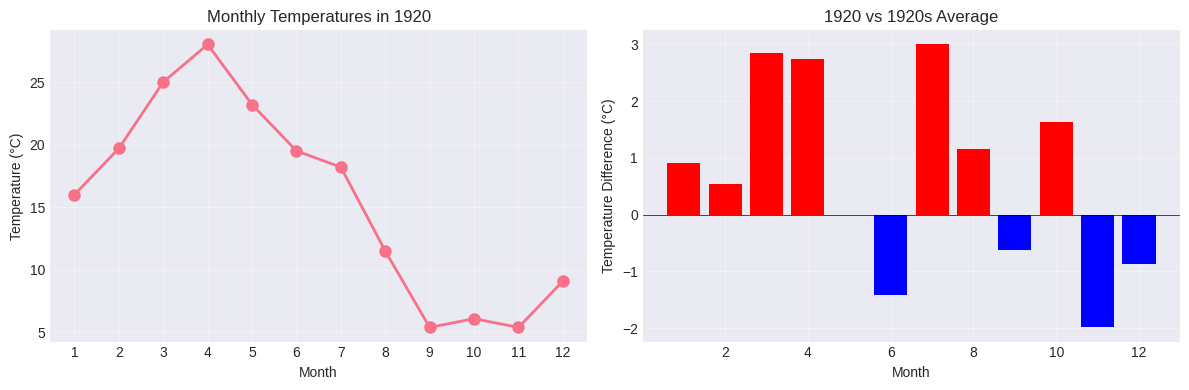


Statistics for 1920:
Average temperature: 15.59°C
Hottest month: 4
Coldest month: 9


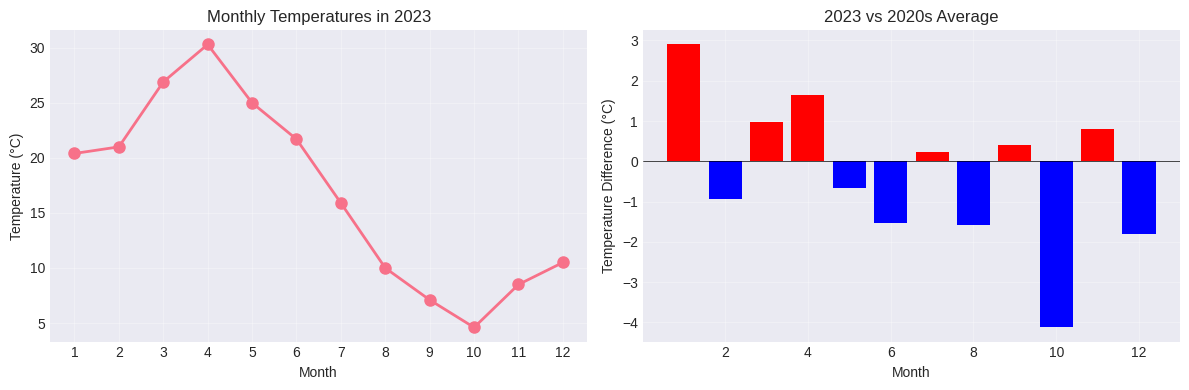


Statistics for 2023:
Average temperature: 16.82°C
Hottest month: 4
Coldest month: 10


In [62]:
# Cell 8: Interactive Investigation
def analyze_year(year):
    """Analyze temperature patterns for a specific year."""
    year_data = df[df['year'] == year]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Monthly temperatures
    axes[0].plot(year_data['month'], year_data['temperature'], 
                 marker='o', linewidth=2, markersize=8)
    axes[0].set_title(f'Monthly Temperatures in {year}')
    axes[0].set_xlabel('Month')
    axes[0].set_ylabel('Temperature (°C)')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(range(1, 13))
    
    # Comparison with decade average
    decade = (year // 10) * 10
    decade_avg = df[df['decade'] == decade].groupby('month')['temperature'].mean()
    
    axes[1].bar(year_data['month'], year_data['temperature'] - decade_avg.values, 
                color=['red' if x > 0 else 'blue' 
                       for x in year_data['temperature'] - decade_avg.values])
    axes[1].set_title(f'{year} vs {decade}s Average')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Temperature Difference (°C)')
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print(f"\nStatistics for {year}:")
    print(f"Average temperature: {year_data['temperature'].mean():.2f}°C")
    print(f"Hottest month: {year_data.loc[year_data['temperature'].idxmax(), 'month']}")
    print(f"Coldest month: {year_data.loc[year_data['temperature'].idxmin(), 'month']}")
    
# Try different years
analyze_year(1920)
analyze_year(2023)

## Sharing Your Research

### Exporting Notebooks

Notebooks can be exported to various formats:

```bash
# HTML (for sharing via web)
jupyter nbconvert --to html your_notebook.ipynb

# PDF (requires LaTeX)
jupyter nbconvert --to pdf your_notebook.ipynb

# Python script
jupyter nbconvert --to python your_notebook.ipynb

# Markdown
jupyter nbconvert --to markdown your_notebook.ipynb
```

## Best Practices for Research Notebooks

1. **Start with purpose**: Document your research questions
2. **Organize logically**: Setup → Data → Analysis → Results
3. **Document everything**: Use markdown cells liberally
4. **Name cells**: Give sections clear headings
5. **Clean before sharing**: Remove experimental/debug cells
6. **Version control**: Notebooks work with Git
7. **Reproducibility**: Include environment info

In [45]:
# Cell to include at the start of shared notebooks
import sys
print(f"Python version: {sys.version}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

Python version: 3.11.11 (main, Jan 14 2025, 22:49:08) [Clang 19.1.6 ]
Pandas version: 2.3.3
NumPy version: 2.3.4
Matplotlib version: 3.10.7


## Review Questions

**1. What is the keyboard shortcut to run a cell and move to the next one?**

- Ctrl + Enter
- **Shift + Enter** ✓
- Alt + Enter
- Enter

**2. Which cell type would you use to write documentation?**

- Code cell
- **Markdown cell** ✓
- Raw cell
- Text cell

**3. What does the `%matplotlib inline` magic command do?**

- Makes plots interactive
- **Displays plots within the notebook** ✓
- Saves plots to files
- Increases plot quality

## Key Terms

- **Jupyter Notebook**: Interactive computing environment combining code, visualizations, and narrative text
- **Cell**: Basic unit of a notebook (Code, Markdown, or Raw)
- **Kernel**: Computational engine that executes the code in the notebook
- **Magic commands**: Special commands prefixed with % that provide additional functionality
- **.ipynb file**: JSON-based file format for Jupyter notebooks
- **nbconvert**: Tool for converting notebooks to other formats (HTML, PDF, etc.)
- **Inline visualization**: Displaying plots and charts directly within the notebook